In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


In [2]:
# CONSTANTS
mu = 0.012150582  # Stosunek masy Księżyca do masy układu Ziema-Księżyc
D_ZK = 1  # Ziemia - Księżyc odległość
M_ZK = 1  # Ziemia - Księżyc masa
V_ang = 1  # prędkość katowa układu ziemia księżyc

In [3]:
def place_equation(t, Y):
    global mu
    x,u,y,v = Y
    r1 =  np.sqrt((x+ mu)**2 + y**2)
    r2 =  np.sqrt((x-1+ mu)**2 + y**2)

    # DERIVATIVES
    xp =  u
    up =  x+2*v - ((1-mu)*(x+mu)/r1**3  +  mu*(x-1+mu)/r2**3)
    yp =  v
    vp =  y-2*u - ((1-mu)*y/r1**3  +  mu*y/r2**3)
    return np.array([xp,up,yp,vp])

In [4]:
# EARTH AND MOON POSITION
mass_centre = np.array([0,0])
Earth_centre = np.array([-mu,0])
Moon_centre = np.array([1-mu,0])

# ASTEROID POSITION AND VELOCITY
x,y = [1.05,0.1]
u,v = [-0.45,-0.25]
start_state = np.array([x,u,y,v])


N = 100
t0 = 0
tk = 5


In [5]:
def print_plot(axes,x_s,y_s,method_name,t_s):
    L1 = [1 - (mu/3)**(1/3),0]
    L2 = [1 + (mu/3)**(1/3),0]
    L3 = [-(1 + (5*mu/12)),0]
    L4 = [0.5 - mu,np.sqrt(3)/2]
    L5 = [0.5 - mu,-np.sqrt(3)/2]

    x_l = [L1[0],L2[0],L3[0],L4[0],L5[0]]
    y_l = [L1[1],L2[1],L3[1],L4[1],L5[1]]






    global Earth_centre,Moon_centre

    axes[0].set_title(f"metoda {method_name} trajektoria (x,y)")
    axes[0].axis('equal')

    axes[0].plot(x_s,y_s)
    axes[0].scatter([Earth_centre[0]],Earth_centre[1],color="green")
    axes[0].scatter(Moon_centre[0],Moon_centre[1],color="grey")
    axes[0].scatter(x_l,y_l,color="orange")


    axes[1].set_title(f"metoda {method_name} x(t)")
    axes[1].plot(t_s,x_s)

    axes[2].set_title(f"metoda {method_name} y(t)")
    axes[2].plot(t_s,y_s)



In [6]:
def inertial_system(axes,x_ast,y_ast,x_earth,y_earth,x_moon,y_moon,method_name):
    axes[3].set_title(f"metoda {method_name} ruch w układzie inercjalnym")
    axes[3].plot(x_ast,y_ast,color='red')
    axes[3].plot(x_earth,y_earth,color='green')
    axes[3].plot(x_moon,y_moon,color='grey')

In [7]:
def test_method(method,h,start_state,t0,tk):
    n = int((tk-t0)/h +1)
    t_s = np.linspace(t0,tk,n+1)

    res = np.array(method(h,start_state,t0,tk))
    x_s = res[:,0]
    y_s = res[:,2]

    fig, axes = plt.subplots(1,4,figsize=(18, 5))
    print_plot(axes,x_s,y_s,method.__name__,t_s)

    X_ast = x_s * np.cos(t_s) - y_s * np.sin(t_s)
    Y_ast = x_s * np.sin(t_s) + y_s * np.cos(t_s)

    X_Ziemia = -mu * np.cos(t_s)
    Y_Ziemia = -mu * np.sin(t_s)

    X_Ksiezyc = (1 - mu) * np.cos(t_s)
    Y_Ksiezyc = (1 - mu) * np.sin(t_s)
    inertial_system(axes,X_ast,Y_ast,X_Ziemia,Y_Ziemia,X_Ksiezyc,Y_Ksiezyc,method.__name__)
    # Liczymy tablicę odległości w każdym kroku czasowym
    odleglosci_od_ziemi = np.sqrt((x_s + mu)**2 + y_s**2)

    # Znajdujemy absolutne minimum w tej tablicy
    najblizszy_dystans = np.min(odleglosci_od_ziemi)

    print(f"Najbliższa odległość asteroidy od Ziemi dla metody {method.__name__} wynosi: {najblizszy_dystans}")

In [8]:
def euler(h,start,beg,end):
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        result.append(y_k)
        displacement = place_equation(0,y_k)
        y_k1 = y_k+ h*displacement
        y_k = y_k1
    result.append(y_k)
    return result

In [9]:
def euler_implicit(h,start,beg,end):
    # 0 = -y_k1 +y_k +h_k * f(t_k1,y_k1)
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        def error(Y_k1):
            derivs = place_equation(0, Y_k1)
            err = Y_k1 - y_k - h * derivs
            return err
        result.append(y_k)
        y_k1 = fsolve(error,y_k)
        y_k = y_k1
    result.append(y_k)
    return result

In [10]:
def euler_semi_implicit(h,start,beg,end):
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        result.append(y_k)

        def error(Y_k1):
            nonlocal y_k
            x_k1,u_k1,y_k1,v_k1 = Y_k1
            x_k0,u_k0,y_k0,v_k0 = y_k
            derivs = place_equation(0, np.array([x_k0,u_k1,y_k0,v_k1]))
            err = Y_k1 - y_k - h * derivs
            return err

        y_k = fsolve(error,y_k)
    result.append(y_k)
    return result


In [11]:
def runge_kutta45(h,start,beg,end):
    n = int((tk-t0)/h +1)
    t_s = np.linspace(t0,tk,n+1)
    return solve_ivp(place_equation,[beg,end],start,t_eval=t_s).y.T

In [12]:
def runge_kutta(h,start,beg,end):
    n = int((end - beg) / h + 1)
    y_k = np.array(start)
    result = []

    for i in range(n):
        result.append(y_k)

        k1 = np.array(place_equation(0, y_k))
        k2 = np.array(place_equation(0, y_k + (h / 2) * k1))
        k3 = np.array(place_equation(0, y_k + (h / 2) * k2))
        k4 = np.array(place_equation(0, y_k + h * k3))


        y_k1 = y_k + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

        y_k = y_k1

    result.append(y_k)
    return result

In [23]:
h = 1e-5


In [14]:
def plot_important_points():
    L1 = [1 - (mu/3)**(1/3),0]
    L2 = [1 + (mu/3)**(1/3),0]
    L3 = [-(1 + (5*mu/12)),0]
    L4 = [0.5 - mu,np.sqrt(3)/2]
    L5 = [0.5 - mu,-np.sqrt(3)/2]

    x_l = [L1[0],L2[0],L3[0],L4[0],L5[0]]
    y_l = [L1[1],L2[1],L3[1],L4[1],L5[1]]





    fig, axes = plt.subplots(figsize=(10, 7))
    global Earth_centre,Moon_centre

    axes.set_title(f"Lagrange points and space objects")
    axes.axis('equal')

    axes.scatter([Earth_centre[0]],Earth_centre[1],color="green")
    axes.scatter(Moon_centre[0],Moon_centre[1],color="grey")
    axes.scatter(x_l,y_l,color="orange")

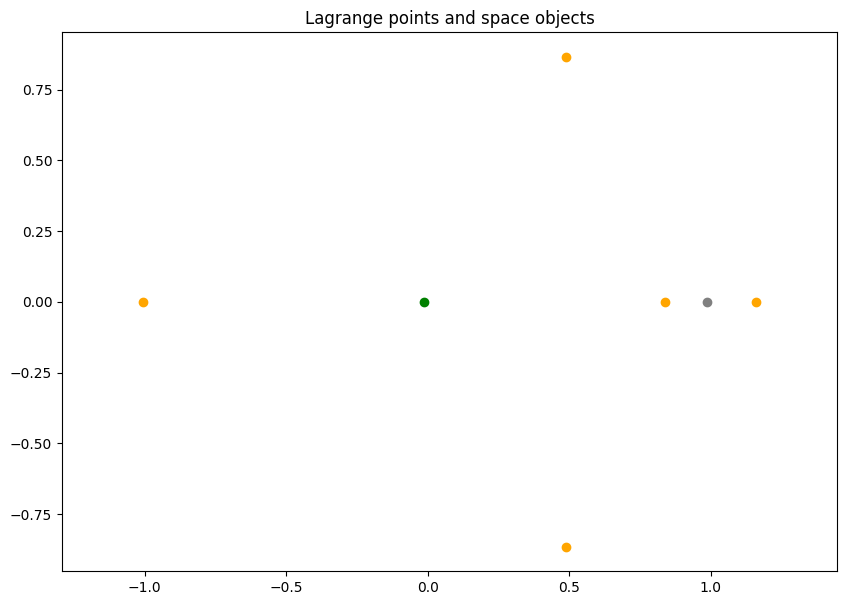

In [15]:
plot_important_points()

Najbliższa odległość asteroidy od Ziemi dla metody euler wynosi: 0.13458650399608385
Najbliższa odległość asteroidy od Ziemi dla metody euler_implicit wynosi: 0.13446465012332356
Najbliższa odległość asteroidy od Ziemi dla metody euler_semi_implicit wynosi: 0.13454712011591047
Najbliższa odległość asteroidy od Ziemi dla metody runge_kutta wynosi: 0.13452552615583882


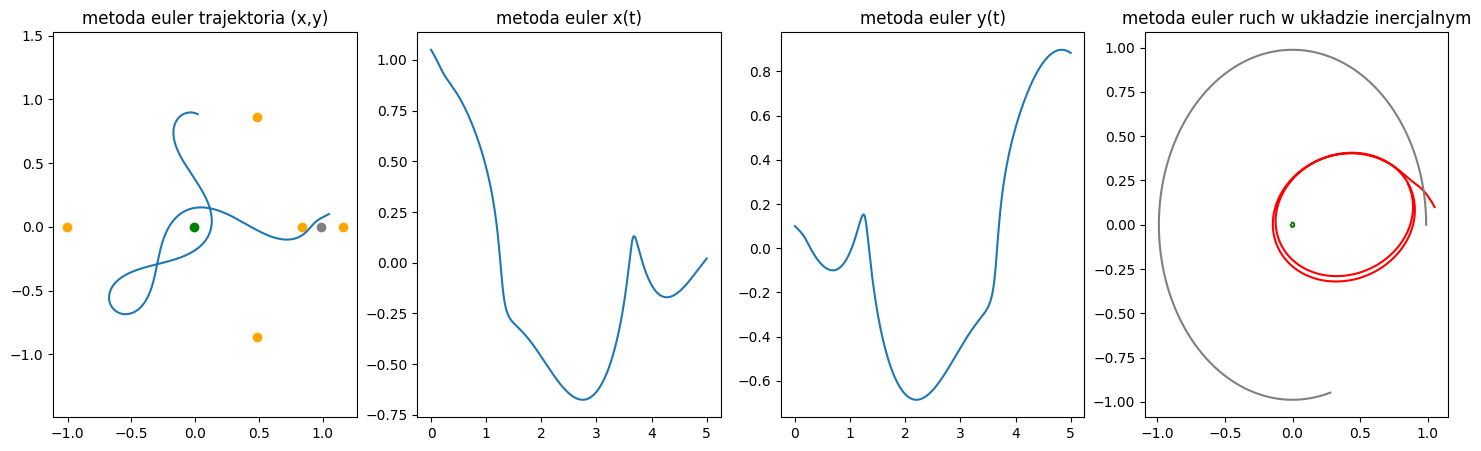

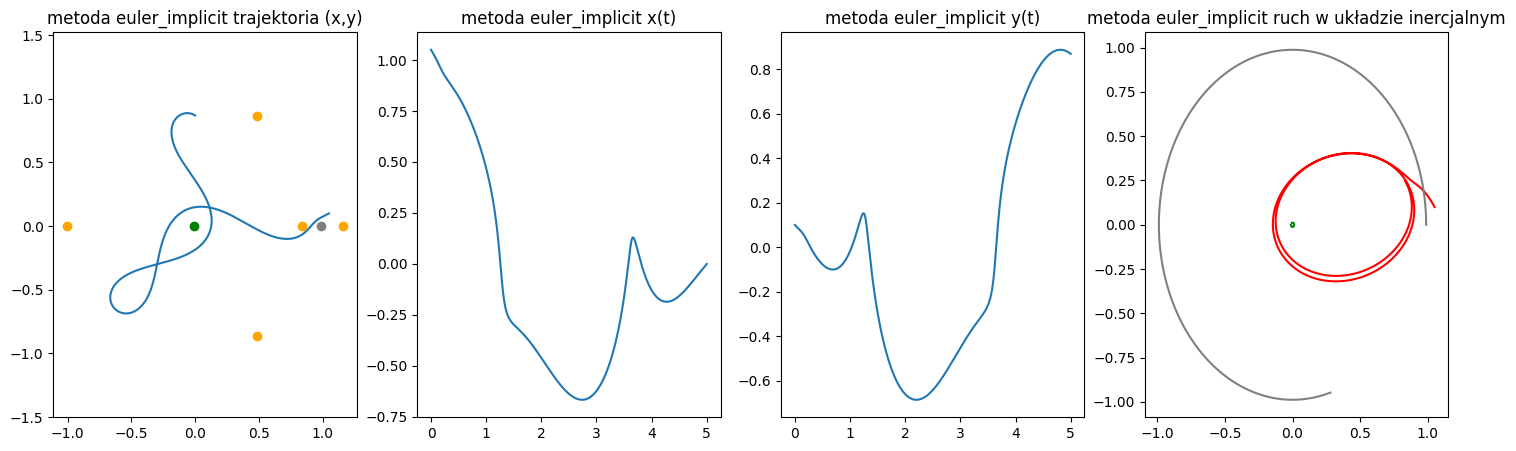

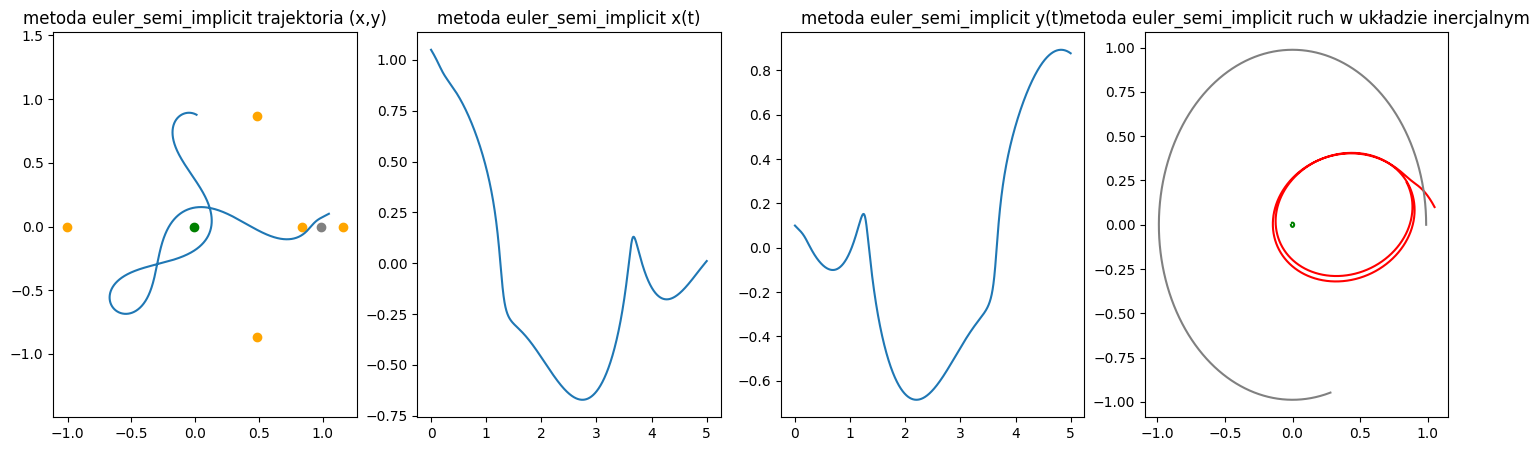

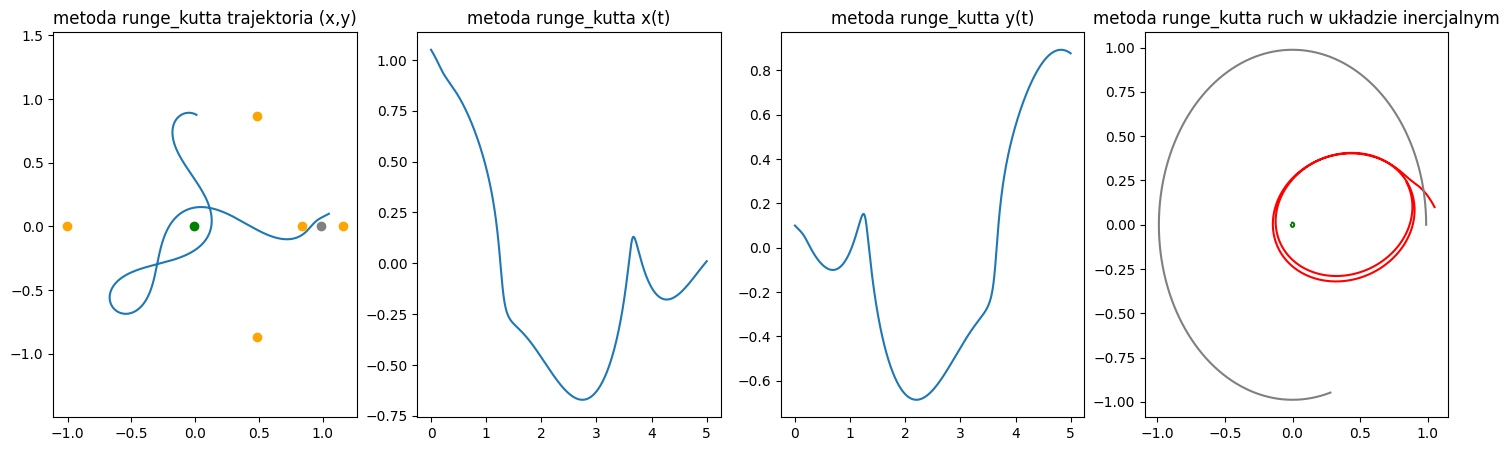

In [24]:
methods = [euler,euler_implicit,euler_semi_implicit,runge_kutta]
for method in methods:
    test_method(method,h,start_state,t0,tk)